In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import json

# 1. Load the rain-lagged dataset
df = pd.read_csv('rain_correlated_lag_dataset.csv')

In [6]:
df.head()

,year,week_no,district,disease_name_in_full_form,cases,cases_lag1,cases_lag2,cases_lag3,cases_lag4,precip_lag1,precip_lag2,precip_lag3,precip_lag4,district_enc,disease_enc,week_sin,week_cos
0,2020,5,Ampara,Dengue Fever,47,14.0,21.0,24.0,9.0,25.10,11.6,13.6,12.8,0,0,0.568065,0.822984
1,2020,6,Ampara,Dengue Fever,40,47.0,14.0,21.0,24.0,0.20,25.1,11.6,13.6,0,0,0.663123,0.748511
2,2020,7,Ampara,Dengue Fever,43,40.0,47.0,14.0,21.0,10.30,0.2,25.1,11.6,0,0,0.748511,0.663123
3,2020,8,Ampara,Dengue Fever,22,43.0,40.0,47.0,14.0,15.50,10.3,0.2,25.1,0,0,0.822984,0.568065
4,2020,9,Ampara,Dengue Fever,12,22.0,43.0,40.0,47.0,16.34,15.5,10.3,0.2,0,0,0.885456,0.464723


In [17]:
df.isnull().sum()

year                         0
week_no                      0
district                     0
disease_name_in_full_form    0
cases                        0
cases_lag1                   0
cases_lag2                   0
cases_lag3                   0
cases_lag4                   0
precip_lag1                  0
precip_lag2                  0
precip_lag3                  0
precip_lag4                  0
district_enc                 0
disease_enc                  0
week_sin                     0
week_cos                     0
dtype: int64

In [8]:
le_dist = LabelEncoder()
le_dis = LabelEncoder()
df['district_enc'] = le_dist.fit_transform(df['district'])
df['disease_enc'] = le_dis.fit_transform(df['disease_name_in_full_form'])

In [9]:
df.to_csv("Final ml trainable dataset.csv")

In [16]:
# 3. Feature Engineering: Cyclical Weeks
df['week_sin'] = np.sin(2 * np.pi * df['week_no'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week_no'] / 52)

# 4. Define Features and Target
# We use all 8 lags you created in the CSV
features = [
    'year', 'week_sin', 'week_cos', 'district_enc', 'disease_enc',
    'cases_lag1', 'cases_lag2', 'cases_lag3', 'cases_lag4',
    'precip_lag1', 'precip_lag2', 'precip_lag3', 'precip_lag4'
]
X = df[features]
y = df['cases']

# 5. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [15]:
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [14]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

preds=model.predict(X_test)

mae=mean_absolute_error(y_test,preds)
rmse=np.sqrt(mean_squared_error(y_test,preds))
r2=r2_score(y_test,preds)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 3.2607455253601074
RMSE: 12.00145204024158
R2: 0.8486728072166443


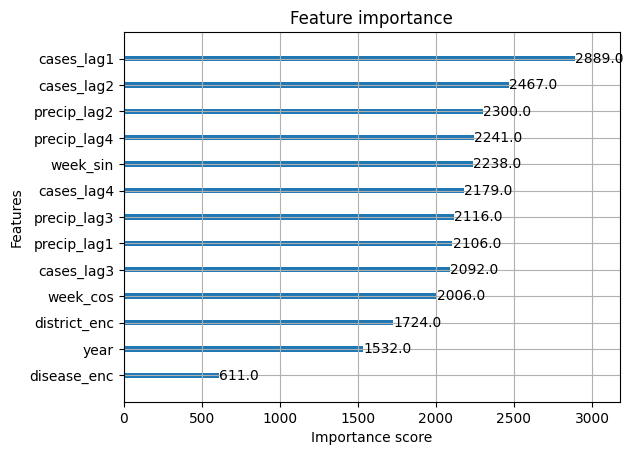

<Figure size 1000x600 with 0 Axes>

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

xgb.plot_importance(model)
plt.show()

plt.figure(figsize=(10,6))
plt.show()

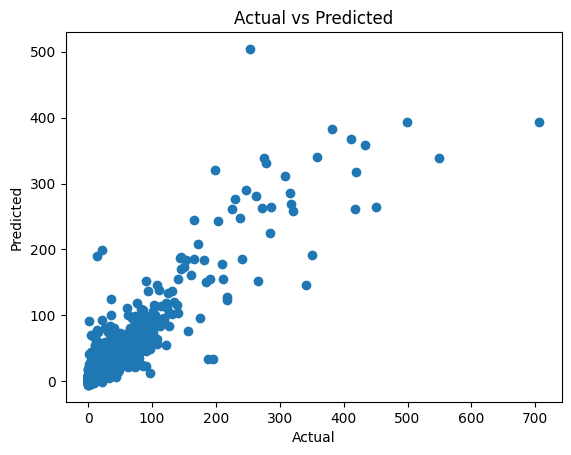

In [4]:
plt.scatter(y_test,preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
# 6. Export Native JSON
model.save_model('xgb_rain_model.json')

metadata = {
    "feature_names": features,
    "district_classes": le_dist.classes_.tolist(),
    "disease_classes": le_dis.classes_.tolist()
}
with open('rain_model_metadata.json', 'w') as f:
    json.dump(metadata, f)

print("Success: Model trained with rain patterns and exported.")